
# Przygotowanie

Przygotowanie
Przed rozpoczęciem pracy z notatnikiem proszę zmienić jego nazwę dodając na początku numer albumu, imię i nazwisko. {nr_albumu}_{imię}_{nazwisko}_{nazwa}

Po wykonaniu wszystkich zadań proszę przesłać wypełniony notatnik przez platformę TEAMS.

# Support Vector Machine

Jest to jeden z najbardziej rozpowszechnionych i wszechstronnych modeli uczenia maszynowego. Z jego uzyciem dokonac mozna klasyfikacji liniowej (SVC), nieliniowej jak i regresji (SVR). Na poniższej grafice przedstawione zostało działanie klasyfikatora.

![svc](svc.png)

Analizujac grafike dostrzec mozna dwie oddzielne klasy oddzielone za pomoca prostej. Widoczna linia ciagła rozdziela klasy, a przerywane linie oznaczają margines, czyli możliwe najdalsze oddalenie elementu (np. nowego) jaki zakwalifikowany
zostanie do danej klasy. Maszyny SVM czułe sa na skale danych, przed ich uzyciem zawsze powinna zostać przeprowadzona normalizacja danych (np. min-max, lub standaryzacja).

![svc_example](svc2.jpg)

Równowage pomiedzy marginesami możemy regulować za pomoca hipermarapetru
C. Mniejsze jego wartości poszerzają granice, jednocześnie wprowadzając
więcej jej naruszeń. Im margines jest szerszy, tym własciwosci generalizujace
jakie posiada klasyfikator będę większe. Mniejsza staje się podatność na przeuczenie
(ang. overfitting), ale zmniejsza się skuteczność klasyfikatora. Szukany jest
taki klasyfikator, który podzieli przestrzeń na dwa rozłaczne zbiory odpowiadajace
dwóm klasom, w możliwie optymalny sposób. Podejście opiera się na
znalezieniu granicy decyzyjnej.

Wektory nośne (Support vectors) są to obserwacje (data points), które wystepują najbliżej hiperpłaszczyzny. Punkty te, pomagają lepiej wyznaczyć linię separacji pomiędzy klasami poprzez obliczenie marginesów. Są to najbardziej znaczace obserwacje ze zbioru z punktu widzenia konstrukcji klasyfikatora.

Warto zaznaczyć, że za pomocą klasyfikatora SVC można klasyfikaować dane, które nie są linowo separowalne. Można to osiągnąć przez tzw "sztuczkę kernelową", dzięki czemu możliwe jest zmapowanie obserwacji do wielowymiarowej przestrzeni. Klasyfikator z biblioteki Sklearn posiada parametr *kernel*, który pozwala na zmianę jądra. Dodatkowo, parametr *gamma* pozwala na modyfikację działania samego kernela.

Warto zaznaczyć, że SVC dobrze nadaje się do niewielkich zbiorów danych, gdyż w przypadku dużej ilości staję się on mało wydajny.

Funkcja jaka jest minimalizowana podczas działania klasyfikatora wygląda następująco:

\begin{equation}
min C \sum^m_{i=1}[y^{(i)}cost_{1}(\theta^{T}x^{(i)}) - (1 - y^{(i)})cost_{0}(\theta^{T}x^{(i)})] + \frac{1}{2} \sum^{n}_{i=1}\theta^{2}_{j}
\end{equation}

## Zadanie 0 

Wczytanie danych ze zbioru oraz wizualizacja.

In [1]:
import pandas as pd

data_input = pd.read_csv('./Ankieta.csv')
data_input.head()

,Waga,Wzrost,Plec
0,55,160,Kobieta
1,78,180,Mezczyzna
2,55,150,Kobieta
3,99,196,Mezczyzna
4,90,180,Mezczyzna


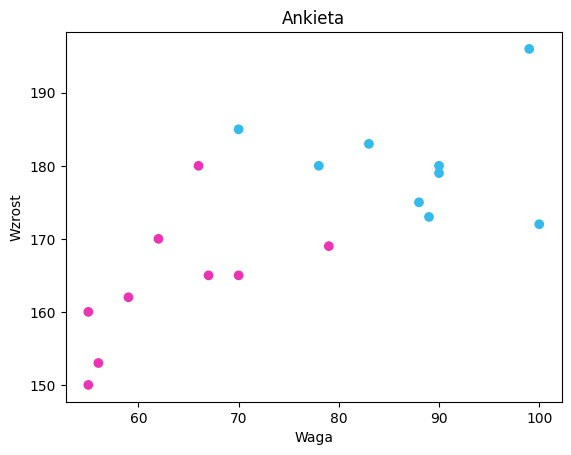

In [2]:
import matplotlib.pyplot as plt
from matplotlib import colors

x = data_input['Plec'].map(lambda x: 1 if x == 'Kobieta' else 0)
y = data_input['Waga']
z = data_input['Wzrost']

data_input['Plec'] = data_input['Plec'].map(lambda x: 1 if x == 'Kobieta' else 0)

plt.scatter(y, z, c=x, cmap=colors.ListedColormap(['#34baeb', '#eb34b4']))
plt.xlabel('Waga')
plt.ylabel('Wzrost')
plt.title('Ankieta')
plt.show()

C:\Users\Iza\AppData\Local\Temp\ipykernel_16356\1618543461.py:4: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  data_input.hist(ax=ax)


array([[<Axes: title={'center': 'Waga'}>,
        <Axes: title={'center': 'Wzrost'}>],
       [<Axes: title={'center': 'Plec'}>, <Axes: >]], dtype=object)

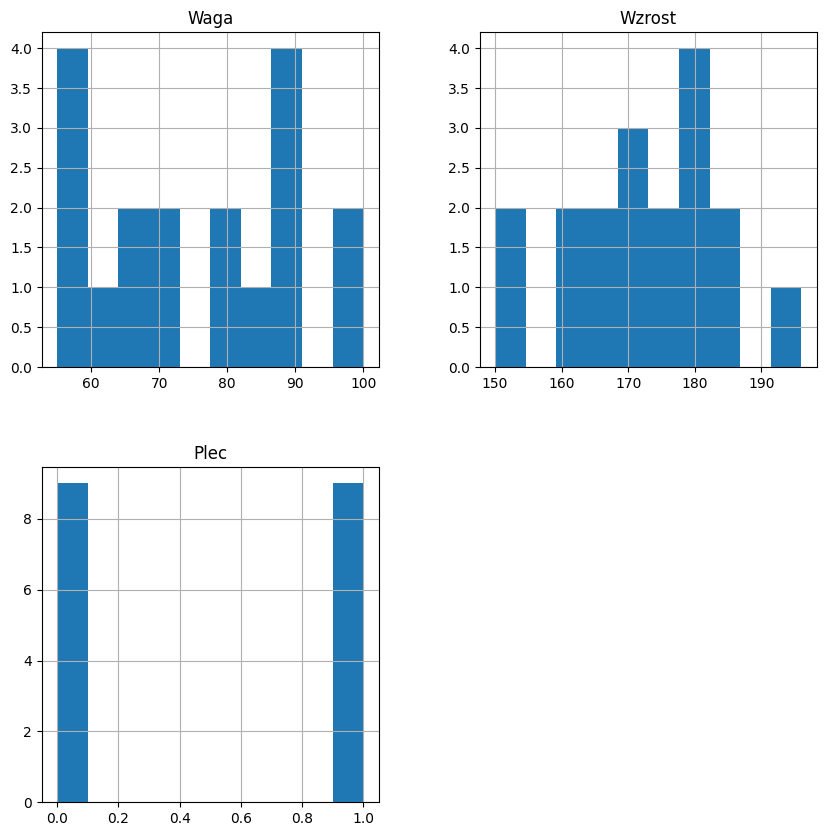

In [3]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize = (10,10))
ax = fig.gca()
data_input.hist(ax=ax)

<Axes: >

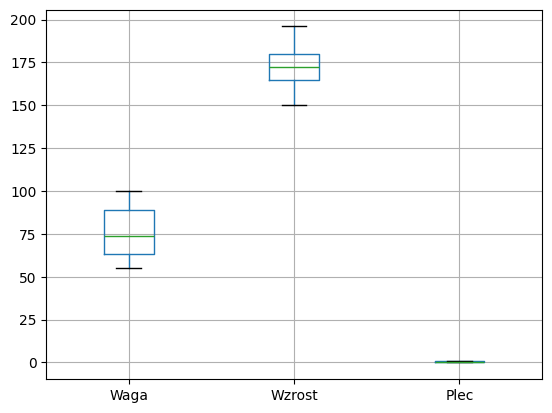

In [4]:
data_input.boxplot()

Na bazie wykresów box-plot można stwierdzić, że dane posiadają różniące się zakresy, co powoduje potrzebę ich skalowania. Warto zauważyć również, że rozkład klas w zbiorze jest równomierny (patrz: histogram)

## Zadanie 1

Proszę dokonać normalizacji zbioru danych za pomocą standaryzacji oraz narysować wykres box-plot dla wszystkich zmiennych. W jaki sposób zmieniły się dane? Co można powiedzieć o ich zakresach. W jakim celu dokonujemy normalizacji?

In [5]:
from sklearn.preprocessing import StandardScaler

X = data_input[['Wzrost', 'Waga']].values
y = data_input['Plec'].values

scaler = StandardScaler()
data_input[['Wzrost_stand', 'Waga_stand']] = scaler.fit_transform(X)

<Axes: >

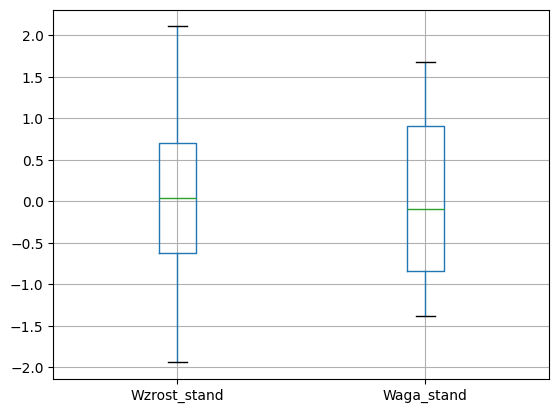

In [6]:
data_input[['Wzrost_stand', 'Waga_stand']].boxplot()

C:\Users\Iza\AppData\Local\Temp\ipykernel_16356\1373805167.py:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  data_input.hist(ax=ax)


array([[<Axes: title={'center': 'Waga'}>,
        <Axes: title={'center': 'Wzrost'}>],
       [<Axes: title={'center': 'Plec'}>,
        <Axes: title={'center': 'Wzrost_stand'}>],
       [<Axes: title={'center': 'Waga_stand'}>, <Axes: >]], dtype=object)

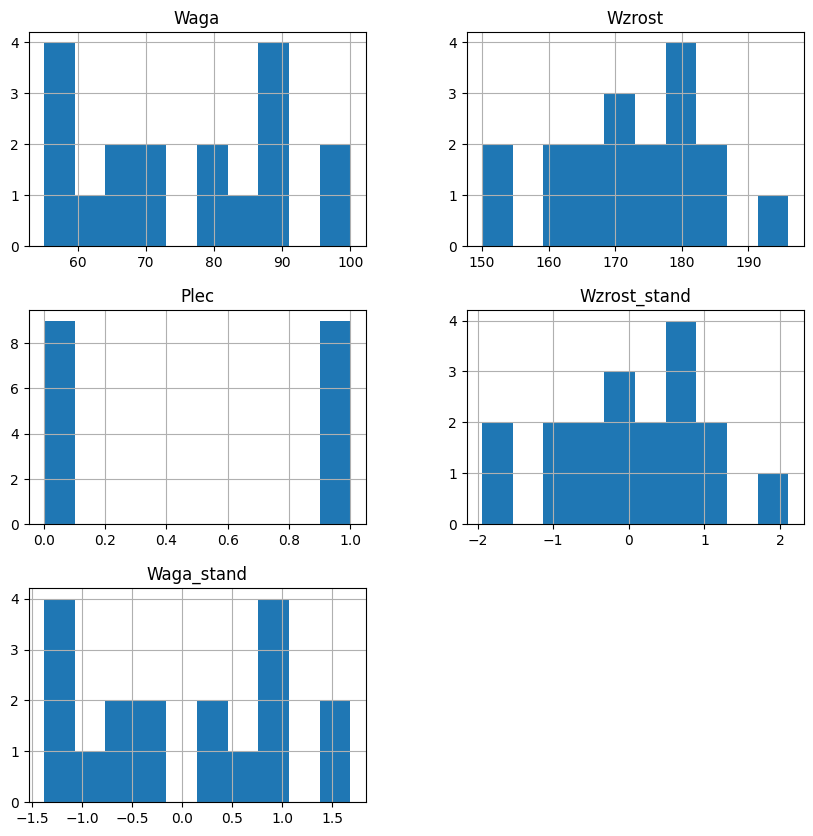

In [7]:
fig = plt.figure(figsize = (10,10))
ax = fig.gca()
data_input.hist(ax=ax)

In [8]:
data_input.describe().round(4)

,Waga,Wzrost,Plec,Wzrost_stand,Waga_stand
count,18.0000,18.0000,18.0000,18.0000,18.0000
mean,75.3333,172.0556,0.5000,0.0000,0.0000
std,15.1152,11.6744,0.5145,1.0290,1.0290
min,55.0000,150.0000,0.0000,-1.9440,-1.3842
25%,63.0000,165.0000,0.0000,-0.6219,-0.8396
50%,74.0000,172.5000,0.5000,0.0392,-0.0908
75%,88.7500,180.0000,1.0000,0.7002,0.9134
max,100.0000,196.0000,1.0000,2.1105,1.6792


Wykonanie standaryzacji pozwoli ujednolicić skalę cech wykorzystanych do nauki modelu. Spowoduje to równomierny wpłuw na działanie klasyfikatora - przed standaryzacjązarkes wartości wagi oraz wzrostu znacznie się różniły. Poprawi to stabilnosc obliczeń i zwiększy skuteczność.

## Zadanie 2

W tym zadaniu należy dokonać podziału zbioru danych na uczący oraz testowy. Zbiór uczący będzie służył do treningu klasyfikatora, a testowy do obliczenia ostatecznej skuteczności klasyfikacji. Prosze, by 80% próbek znalazło się w zbiorze uczącym, a 20% w testowym. Proszę zadbać o odpowiednią inicjalizacje generatora pseudolosowego

In [9]:
from sklearn.model_selection import train_test_split

y = data_input['Plec'].values
X = data_input[['Wzrost', 'Waga']].values


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) #stratify=y proporcje klas w treningu i teście będą zachowane

In [10]:
y_stand = data_input['Plec'].values
X_stand = data_input[['Wzrost_stand', 'Waga_stand']].values


X_stand_train, X_stand_test, y_stand_train, y_stand_test = train_test_split(X_stand, y_stand, test_size=0.2,random_state=42, stratify=y)

## Zadanie 3

W tym zadaniu należy dokonać klasyfikacji danych za pomocą klasyfikatora SVC. Proszę obliczyć skuteczność klasyfikatora na danych po, oraz przed standaryzacją i porównać wyniki.

In [11]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [12]:
svc_std = SVC(kernel='rbf', random_state=42)
svc_std.fit(X_stand_train, y_stand_train)

y_pred_std = svc_std.predict(X_stand_test)
acc_std = accuracy_score(y_stand_test, y_pred_std) * 100
#=======================
svc_raw = SVC(kernel='rbf', random_state=42)
svc_raw.fit(X_train, y_train)

y_pred = svc_raw.predict(X_test)
acc_raw = accuracy_score(y_test, y_pred)*100

y_pred_train_raw = svc_raw.predict(X_train)
acc_train_raw = accuracy_score(y_train, y_pred_train_raw) * 100

y_pred_train_std = svc_std.predict(X_stand_train)
acc_train_std = accuracy_score(y_stand_train, y_pred_train_std) * 100

print('RBF')
print(f"Skuteczność SVC na treningu bez standaryzacji: {acc_train_raw:.2f}%")
print(f"Skuteczność SVC na treningu po standaryzacji: {acc_train_std:.2f}%")

print('---------------')
print(f"Skuteczność SVC bez standaryzacji: {acc_raw:.2f}%")
print(f"Skuteczność SVC po standaryzacji: {acc_std:.2f}%")

RBF
Skuteczność SVC na treningu bez standaryzacji: 92.86%
Skuteczność SVC na treningu po standaryzacji: 100.00%
---------------
Skuteczność SVC bez standaryzacji: 75.00%
Skuteczność SVC po standaryzacji: 100.00%


In [13]:
svc_std = SVC(kernel='linear', random_state=42)
svc_std.fit(X_stand_train, y_stand_train)

y_pred_std = svc_std.predict(X_stand_test)
acc_std = accuracy_score(y_stand_test, y_pred_std) * 100

#=====================
svc_raw = SVC(kernel='linear', random_state=42)
svc_raw.fit(X_train, y_train)

y_pred_raw = svc_raw.predict(X_test)
acc_raw = accuracy_score(y_test, y_pred_raw) * 100

y_pred_train_raw = svc_raw.predict(X_train)
acc_train_raw = accuracy_score(y_train, y_pred_train_raw) * 100

y_pred_train_std = svc_std.predict(X_stand_train)
acc_train_std = accuracy_score(y_stand_train, y_pred_train_std) * 100

print('LINEAR')
print(f"Skuteczność SVC na treningu bez standaryzacji: {acc_train_raw:.2f}%")
print(f"Skuteczność SVC na treningu po standaryzacji: {acc_train_std:.2f}%")

print('---------------')
print(f"Skuteczność SVC bez standaryzacji: {acc_raw:.2f}%")
print(f"Skuteczność SVC po standaryzacji: {acc_std:.2f}%")

LINEAR
Skuteczność SVC na treningu bez standaryzacji: 100.00%
Skuteczność SVC na treningu po standaryzacji: 100.00%
---------------
Skuteczność SVC bez standaryzacji: 100.00%
Skuteczność SVC po standaryzacji: 75.00%


In [14]:
svc_std = SVC(kernel='poly', degree=3, random_state=42)
svc_std.fit(X_stand_train, y_stand_train)

y_pred_std = svc_std.predict(X_stand_test)
acc_std = accuracy_score(y_stand_test, y_pred_std) * 100

#===================================
svc_raw = SVC(kernel='poly', degree=3, random_state=42)
svc_raw.fit(X_train, y_train)

y_pred_raw = svc_raw.predict(X_test)
acc_raw = accuracy_score(y_test, y_pred_raw) * 100

y_pred_train_raw = svc_raw.predict(X_train)
acc_train_raw = accuracy_score(y_train, y_pred_train_raw) * 100

y_pred_train_std = svc_std.predict(X_stand_train)
acc_train_std = accuracy_score(y_stand_train, y_pred_train_std) * 100

print('POLY')
print(f"Skuteczność SVC na treningu bez standaryzacji: {acc_train_raw:.2f}%")
print(f"Skuteczność SVC na treningu po standaryzacji: {acc_train_std:.2f}%")

print('---------------')
print(f"Skuteczność SVC bez standaryzacji: {acc_raw:.2f}%")
print(f"Skuteczność SVC po standaryzacji: {acc_std:.2f}%")

POLY
Skuteczność SVC na treningu bez standaryzacji: 100.00%
Skuteczność SVC na treningu po standaryzacji: 78.57%
---------------
Skuteczność SVC bez standaryzacji: 100.00%
Skuteczność SVC po standaryzacji: 50.00%


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

color_men = '#34baeb'
color_women = '#eb34b4'

def plot_decision_boundary(model, X_train, y_train, X_test=None, y_test=None, 
                           title='', xlabel='', ylabel='', margin=0.05):
    h = 0.5

    # łączymy wszystkie dane, żeby wyznaczyć zakres osi
    X_all = X_train if X_test is None else np.vstack([X_train, X_test])
    
    x_range = X_all[:, 0].max() - X_all[:, 0].min()
    y_range = X_all[:, 1].max() - X_all[:, 1].min()

    x_min = X_all[:, 0].min() - x_range * margin
    x_max = X_all[:, 0].max() + x_range * margin
    y_min = X_all[:, 1].min() - y_range * margin
    y_max = X_all[:, 1].max() + y_range * margin

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    cmap_light = ListedColormap([color_men, color_women])
    cmap_bold = ListedColormap([color_men, color_women])

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_light)

    #zbiór treningowy
    plt.scatter(
        X_train[:, 0],
        X_train[:, 1],
        c=y_train,
        cmap=cmap_bold,
        edgecolor='k',
        marker='o',   # okrąg
        s=80,
        label='Train'
    )

    # jeśli podano zbiór testowy, rysujemy go innym markerem
    if X_test is not None and y_test is not None:
        plt.scatter(
            X_test[:, 0],
            X_test[:, 1],
            c=y_test,
            cmap=cmap_bold,
            edgecolor='k',
            marker='s',  # kwadrat
            s=80,
            label='Test'
        )

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.legend()
    plt.show()


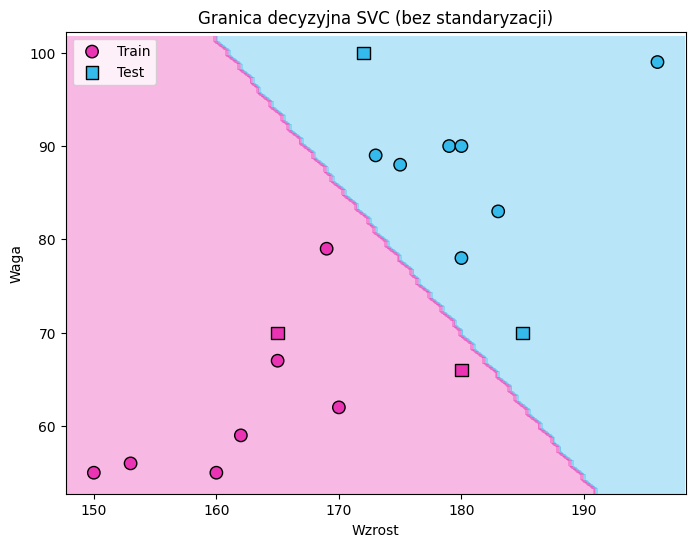

In [16]:
plot_decision_boundary(svc_raw, X_train, y_train, X_test, y_test,
    title="Granica decyzyjna SVC (bez standaryzacji)",
    xlabel="Wzrost",
    ylabel="Waga"
)

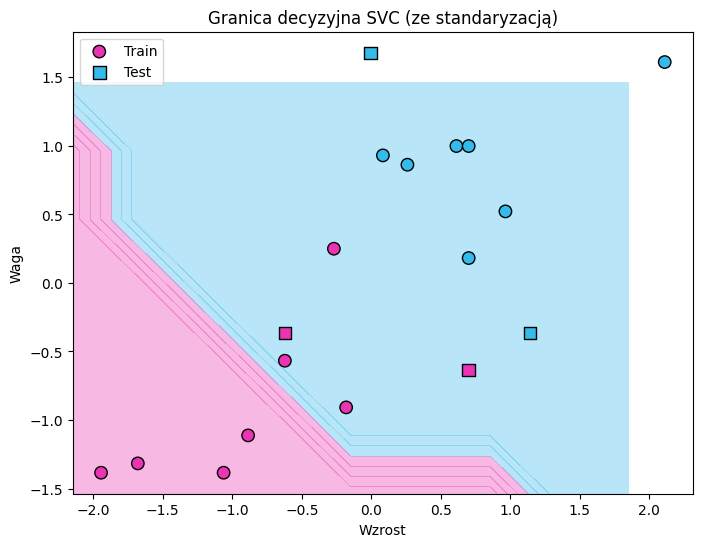

In [17]:
plot_decision_boundary(svc_std, X_stand_train, y_stand_train, X_stand_test, y_stand_test,
    title="Granica decyzyjna SVC (ze standaryzacją)",
    xlabel="Wzrost",
    ylabel="Waga"
)

Analizując skuteczność klasyfikatorów SVC z różnymi kernelami zaobserwowano, że dla SVC z jądrem liniowym (linear) uzyskano najlepsze wyniki na zbiorze treningowym - zarówno dla danych przed i po standaryzacji skuteczność osiąśgnęła 100%, co przełożyło się na dobre dopasowanie do danych testowych.

Bez standaryzacji: 100.00%
Po standaryzacji: 75.00%

Dane wizualnie są niemal liniowo separowalne (jak widać na wykresie granicy decyzyjnej), dlatego kernel liniowy  najlepiej dopasowuje się do danych.

## Zadanie 4

Proszę dobrać odpowiedni parametr C (proszę spróbować z zakresu -1, 1 z krokiem co 0.1). Dla każdego C proszę wyrysować hiperpłaszczyznę utworzoną przez klasyfikator (w formie animimacji, lub inaczej). Proszę przedstawić na wykresie jak zmieniała się skuteczność klasyfikatora w zależności od parametru C. Jakie wnioski można wyciągnąć? Jak wpływa parametr C na wynik?

In [18]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Kolory
color_men = '#34baeb'
color_women = '#eb34b4'

C_values = np.arange(0.1, 1.1, 0.1)

h = 0.02
x_min, x_max = X_stand_train[:, 0].min() - 1, X_stand_train[:, 0].max() + 1
y_min, y_max = X_stand_train[:, 1].min() - 1, X_stand_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

cmap_light = ListedColormap([color_men+'55', color_women+'55'])

fig, ax = plt.subplots(figsize=(6,5))

# Funkcja aktualizująca dla animacji
def update(frame):
    ax.clear()
    C = C_values[frame]
    
    svc = SVC(kernel='linear', C=C, random_state=42)
    svc.fit(X_stand_train, y_stand_train)
    
    y_pred_train = svc.predict(X_stand_train)
    y_pred_test = svc.predict(X_stand_test)
    train_skut = accuracy_score(y_stand_train, y_pred_train) * 100
    test_skut = accuracy_score(y_stand_test, y_pred_test) * 100
    
    # Granica decyzyjna
    Z = svc.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
    
    # Punkty treningowe
    for i, color in enumerate([color_men, color_women]):
        ax.scatter(X_stand_train[y_stand_train==i, 0],
                   X_stand_train[y_stand_train==i, 1],
                   c=color, marker='o', edgecolor='k', s=50, label=f"Trening {i}" if frame==0 else "")
    
    for i, color in enumerate([color_men, color_women]):
        ax.scatter(X_stand_test[y_stand_test==i, 0],
                   X_stand_test[y_stand_test==i, 1],
                   c=color, marker='^', edgecolor='k', s=80, label=f"Test {i}" if frame==0 else "")
    
    ax.set_xlabel('Wzrost standaryzowany')
    ax.set_ylabel('Waga standaryzowana')
    ax.set_title(f"C={C:.1f}\nSkuteczność trening={train_skut:.1f}%, test={test_skut:.1f}%")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    if frame==0:
        ax.legend(loc='upper left', fontsize=8)

# Tworzymy animację
ani = FuncAnimation(
    fig,
    update,
    frames=len(C_values),
    interval=700,
    repeat=True,
    blit=False
)

plt.close(fig)
HTML(ani.to_jshtml())

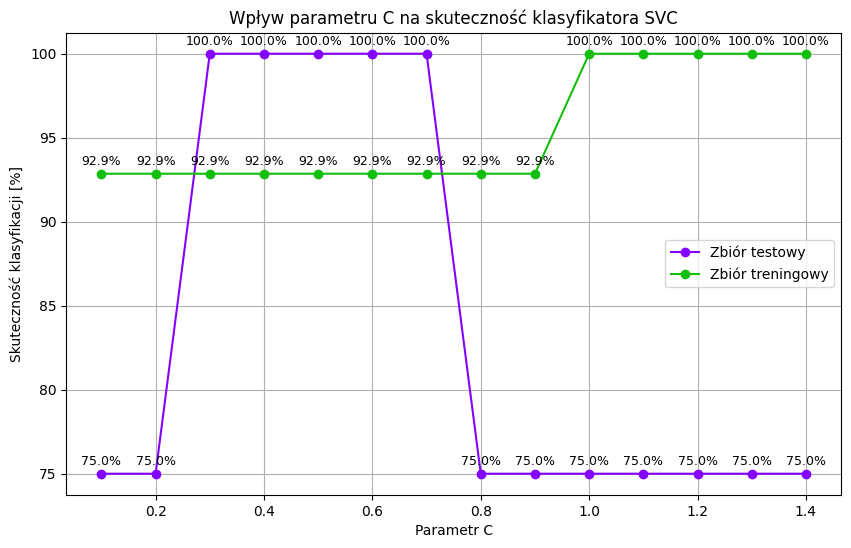

In [19]:
C_values = np.arange(0.1, 1.5, 0.1)

accuracies_train = []
accuracies_test = []

for C in C_values:
    svc = SVC(kernel='linear', C=C, random_state=42)
    svc.fit(X_stand_train, y_stand_train)
    
    y_pred_train = svc.predict(X_stand_train)
    y_pred_test = svc.predict(X_stand_test)
    
    train_acc = accuracy_score(y_stand_train, y_pred_train) * 100
    test_acc = accuracy_score(y_stand_test, y_pred_test) * 100
    
    accuracies_train.append(train_acc)
    accuracies_test.append(test_acc)
    
plt.figure(figsize=(10, 6))
plt.plot(C_values, accuracies_test, marker='o', color='#8403fc', label='Zbiór testowy')
plt.plot(C_values, accuracies_train, marker='o', color='#13bf0d', label='Zbiór treningowy')


for x, y in zip(C_values, accuracies_test):
    plt.text(x, y+0.5, f"{y:.1f}%", ha='center', fontsize=9)
for x, y in zip(C_values, accuracies_train):
    plt.text(x, y+0.5, f"{y:.1f}%", ha='center', fontsize=9)

plt.xlabel('Parametr C')
plt.ylabel('Skuteczność klasyfikacji [%]')
plt.title('Wpływ parametru C na skuteczność klasyfikatora SVC')
plt.grid(True)
plt.legend()
plt.show()

Przetestowano wartości parametru C z zakresu 0.1 - 1.4, zwiększano maksymalną sugerowaną wartość, ponieważ od C=1 skuteczność zbioru treningowego uległa zmianie. Na przygotowanej animacji możemy zaobserwować jak wygląda granica decyzyjna wraz ze zmieniającym się C.

Skuteczność dla zbioru treningowego jest stabilna i wysoka dla większości C, ale wzrasta do 100% od C=1.0. Skuteczność testowa najwyższa (100%) dla C ≈ 0.3–0.7, a przy mniejszych lub większych C spada do 75%. 

Widać klasyczny efekt overfittingu: przy bardzo dużych C model dopasowuje się do treningu (100% skuteczność na treningu), ale na testowych danych spada do 75%.

Można zaobserwować, że domyślnie ustawione C=1.0 nie jest najlepszym wyborem, a będzie nim wartość z przedziału 0.3 - 0.7,

## Zadanie 5

Proszę dokonać pomiaru czasu wykonania algorytmu dla min. 2 różnych kerneli

In [20]:
from time import time

kernels = ['linear', 'rbf', 'poly', 'sigmoid']

for kernel in kernels:
    start = time()
    svc = SVC(kernel=kernel, random_state=42, C=0.6)
    svc.fit(X_stand_train, y_stand_train)
    end = time()
    print(f'Czas trenowania kernel {kernel:6s}: {end - start:.8f} s')

Czas trenowania kernel linear: 0.00400686 s
Czas trenowania kernel rbf   : 0.00199318 s
Czas trenowania kernel poly  : 0.00296903 s
Czas trenowania kernel sigmoid: 0.00229120 s


Różnice czasowe nie są znaczące. Najszybciej z problemem poradziło sobie jądro RBF, a najwolniej Linear.

### Dla zbioru *dataR2* proszę dokonać podobnej analizy danych. Opis zbioru: https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Coimbra

## Zadanie 6

Proszę zwizualizować dane dla 2 dowolnych zmiennych ze zbioru

In [21]:
df_r2 = pd.read_csv('dataR2.csv')
df_r2.head()

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,1
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,1
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,1
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,1
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,1


In [22]:
df_r2.describe()

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
count,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000
mean,57.301724,27.582111,97.793103,10.012086,2.694988,26.615080,10.180874,14.725966,534.647000,1.551724
std,16.112766,5.020136,22.525162,10.067768,3.642043,19.183294,6.843341,12.390646,345.912663,0.499475
min,24.000000,18.370000,60.000000,2.432000,0.467409,4.311000,1.656020,3.210000,45.843000,1.000000
25%,45.000000,22.973205,85.750000,4.359250,0.917966,12.313675,5.474283,6.881763,269.978250,1.000000
50%,56.000000,27.662416,92.000000,5.924500,1.380939,20.271000,8.352692,10.827740,471.322500,2.000000
75%,71.000000,31.241442,102.000000,11.189250,2.857787,37.378300,11.815970,17.755207,700.085000,2.000000
max,89.000000,38.578759,201.000000,58.460000,25.050342,90.280000,38.040000,82.100000,1698.440000,2.000000


In [23]:
df_r2['Classification'].unique()

array([1, 2], dtype=int64)

In [24]:
df_r2['Classification'] = df_r2['Classification'].map({1: 0, 2: 1})

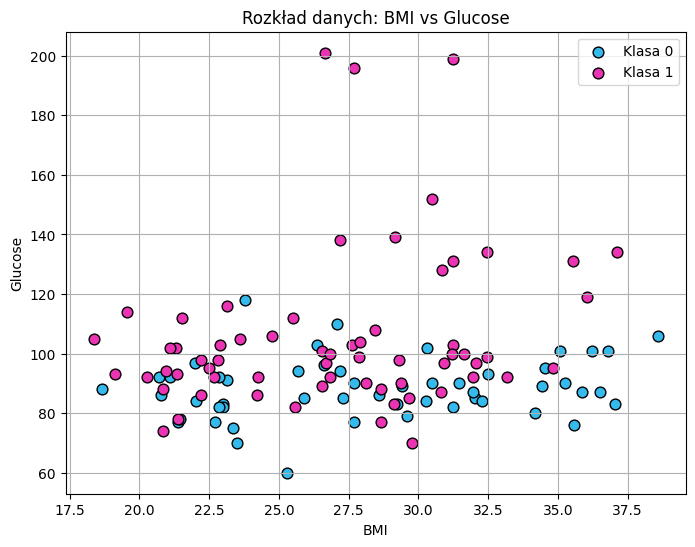

In [25]:
x_var = 'BMI'
y_var = 'Glucose'

# Kolory dla klas
color_0 = '#34baeb'  # klasa 0
color_1 = '#eb34b4'  # klasa 1

plt.figure(figsize=(8,6))
for cls, color, label in zip([0,1], [color_0, color_1], ['Klasa 0', 'Klasa 1']):
    plt.scatter(
        df_r2[df_r2['Classification']==cls][x_var],
        df_r2[df_r2['Classification']==cls][y_var],
        c=color,
        label=label,
        edgecolor='k',
        s=60
    )

plt.xlabel(x_var)
plt.ylabel(y_var)
plt.title(f'Rozkład danych: {x_var} vs {y_var}')
plt.legend()
plt.grid(True)
plt.show()

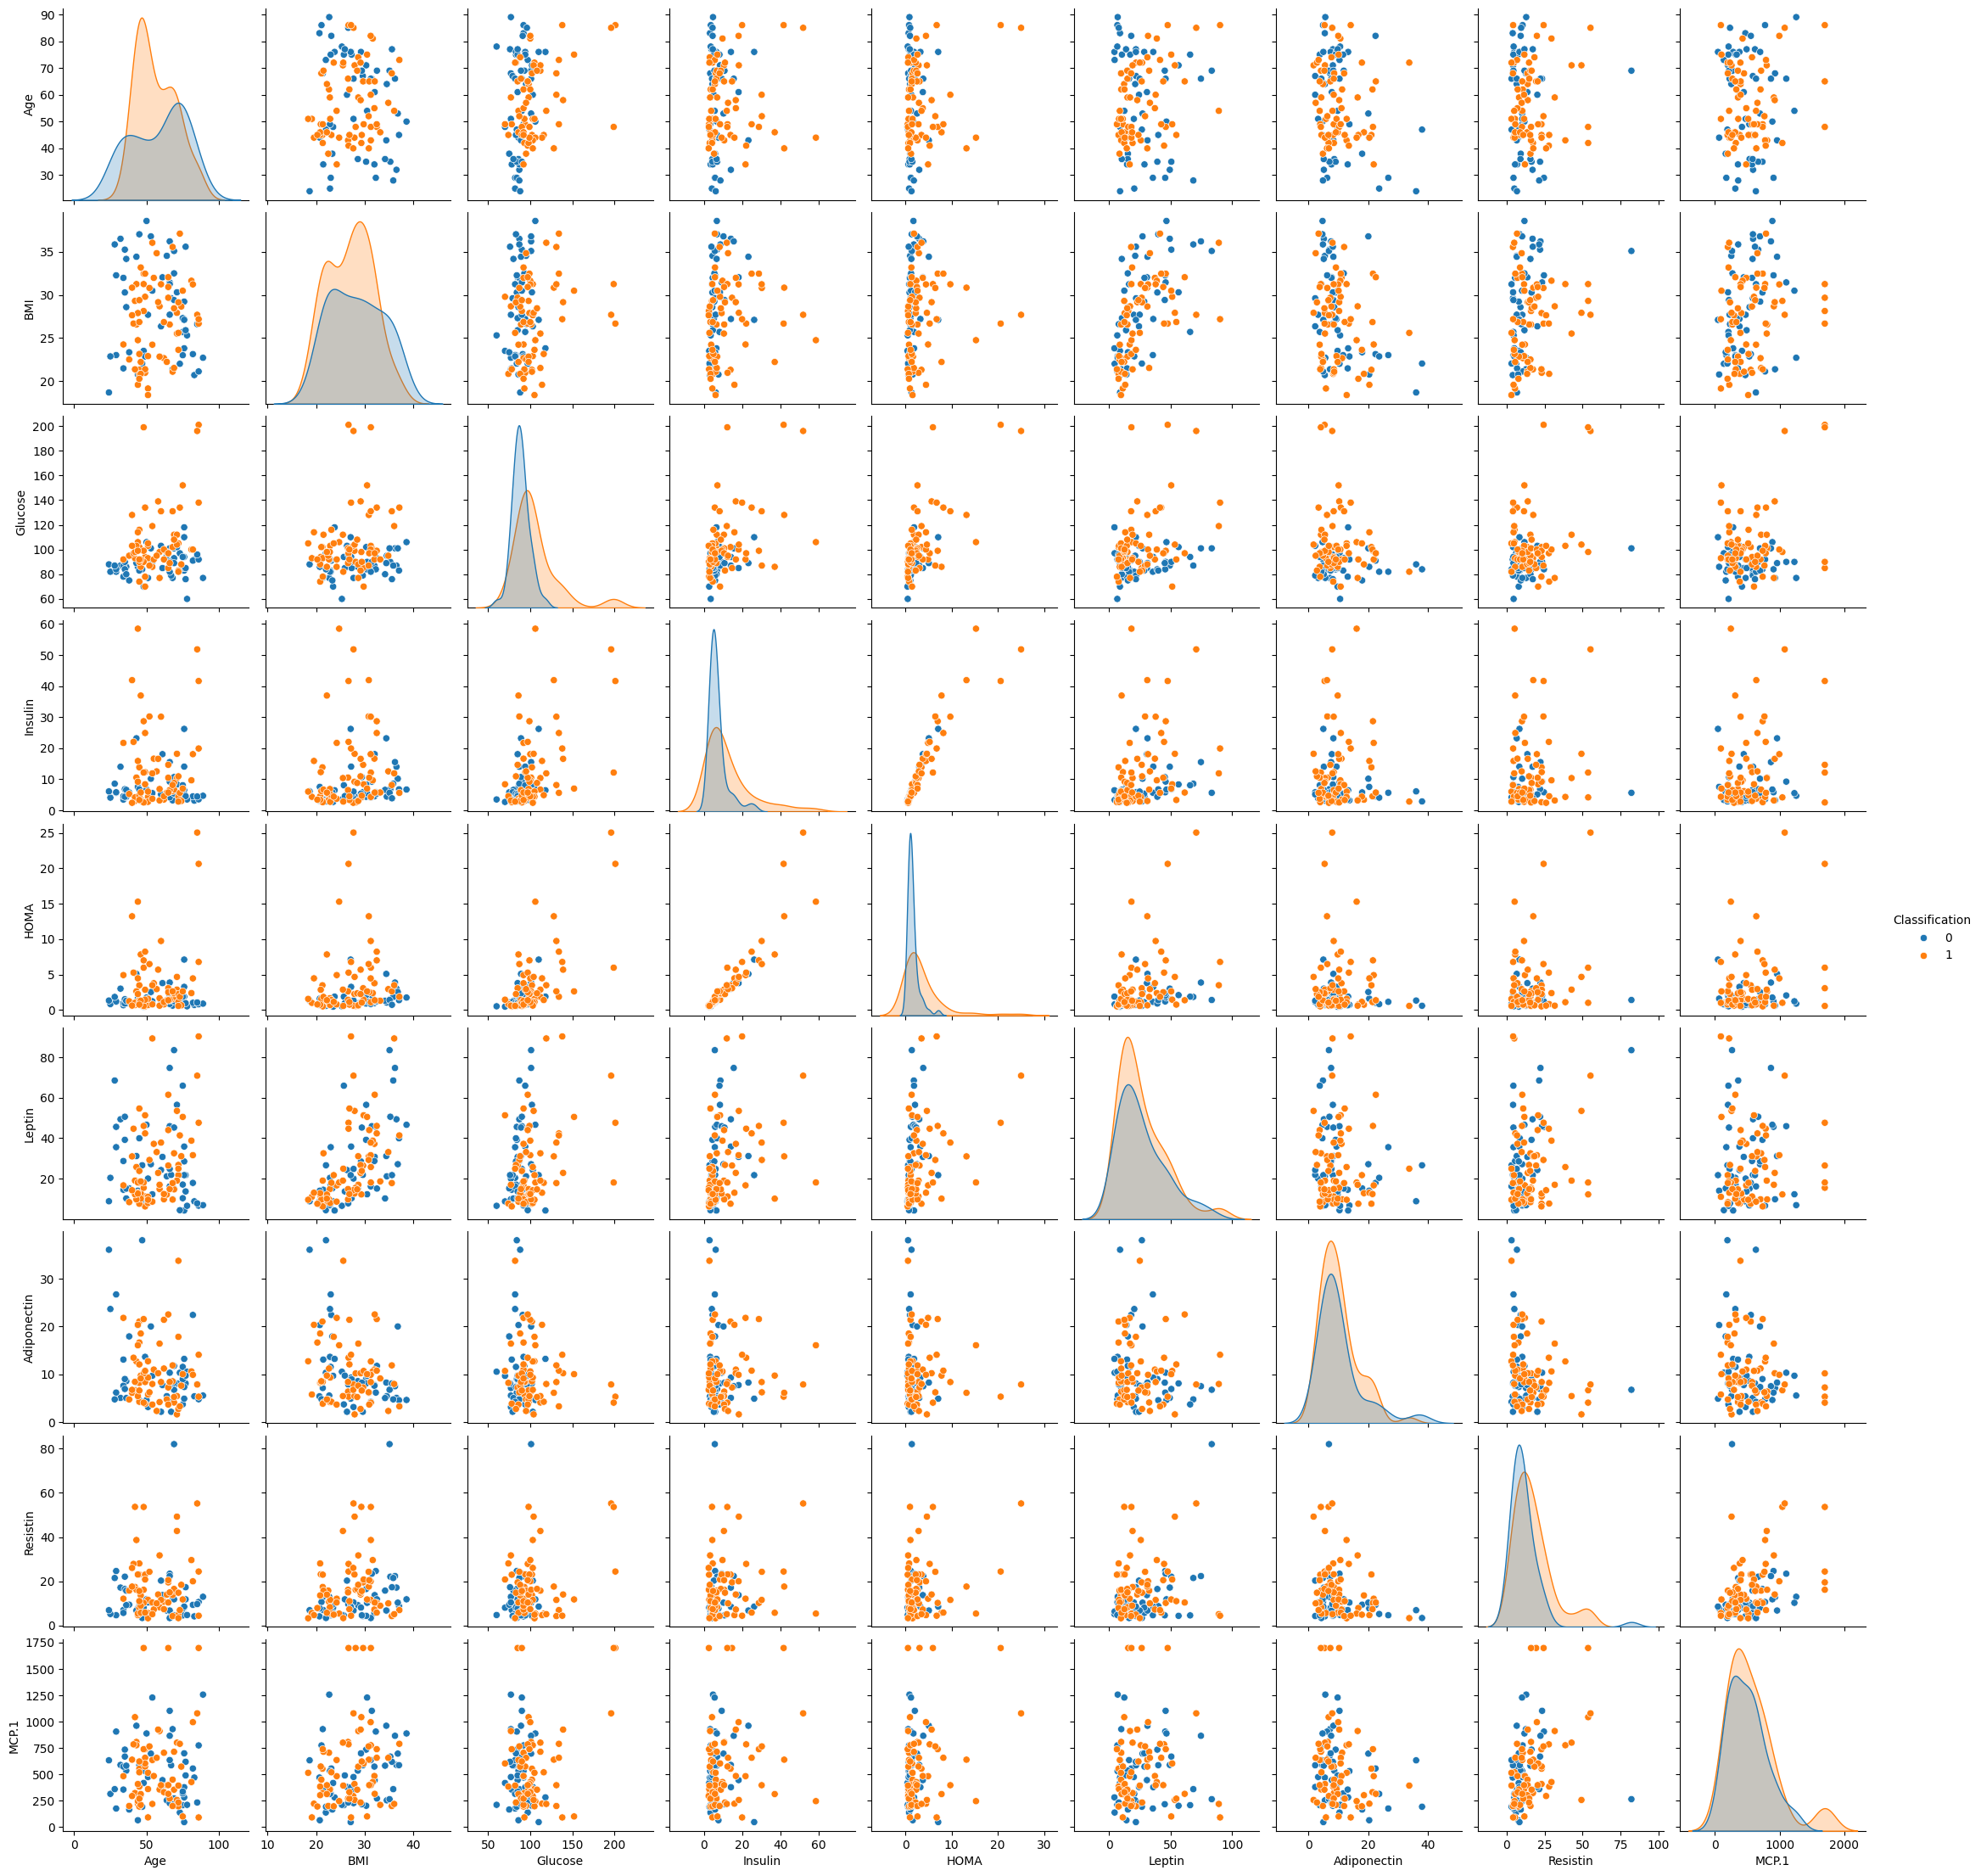

In [26]:
import seaborn as sns
sns.pairplot(df_r2, hue='Classification')

## Zadanie 7

Proszę dokonać standaryzacji danych

In [27]:
X = df_r2[['Glucose', 'BMI']].values
y = df_r2['Classification'].values

scaler = StandardScaler()
X_stand = scaler.fit_transform(X)

Text(0, 0.5, 'Wartości cech')

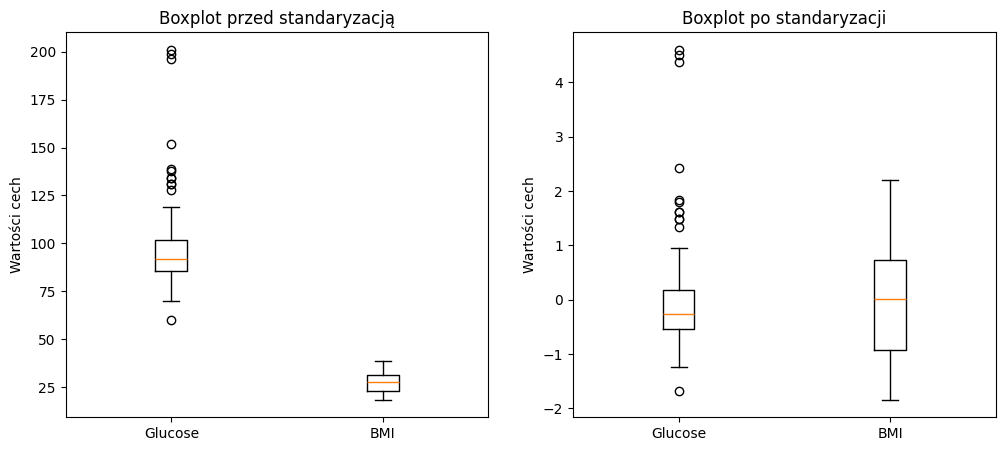

In [28]:
features = ['Glucose', 'BMI']

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Boxplot przed standaryzacją
axes[0].boxplot(X, labels=features)
axes[0].set_title('Boxplot przed standaryzacją')
axes[0].set_ylabel('Wartości cech')

# Boxplot po standaryzacji
axes[1].boxplot(X_stand, labels=features)
axes[1].set_title('Boxplot po standaryzacji')
axes[1].set_ylabel('Wartości cech')

## Zadanie 8

Trenowanie klasyfikatora. Proszę dokonać treningu klasyfikatora na zbiorze treningowym (X_train, y_train). Proszę użyć różnych wartości parametru C, gamma oraz kernel. Pełna dokumentacja klasyfikatora: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html Wyniki proszę podsumować na odpowiednim wykresie lub tabeli. Test skuteczności klasyfikatora proszę dokonać na zbiorze testowym (X_test, y_test).

In [29]:
X_stand_train, X_stand_test, y_stand_train, y_stand_test = train_test_split(
    X_stand, y, test_size=0.2, random_state=42, stratify=y
)

In [46]:
C_values = [0.1, 0.5, 1, 5, 10]
gamma_values = [0.01, 0.1, 1]
kernels = ['linear', 'rbf', 'poly', 'sigmoid']

results = []

for kernel in kernels:
    for C in C_values:
        if kernel == 'linear': # nie obsluguje gammy
            svc = SVC(kernel=kernel, C=C, random_state=42)
            svc.fit(X_stand_train, y_stand_train)
            train_acc = accuracy_score(y_stand_train, svc.predict(X_stand_train))*100
            test_acc = accuracy_score(y_stand_test, svc.predict(X_stand_test))*100
            results.append([kernel, C, '-', train_acc, test_acc])
        else:
            for gamma in gamma_values:
                svc = SVC(kernel=kernel, C=C, gamma=gamma, random_state=42)
                svc.fit(X_stand_train, y_stand_train)
                train_acc = accuracy_score(y_stand_train, svc.predict(X_stand_train))*100
                test_acc = accuracy_score(y_stand_test, svc.predict(X_stand_test))*100
                results.append([kernel, C, gamma, train_acc, test_acc])

df_results = pd.DataFrame(results, columns=['Kernel', 'C', 'Gamma', 'Train Accuracy [%]', 'Test Accuracy [%]'])
df_results

,Kernel,C,Gamma,Train Accuracy [%],Test Accuracy [%]
0,linear,0.1,-,68.478261,75.000000
1,linear,0.5,-,71.739130,75.000000
2,linear,1.0,-,68.478261,75.000000
3,linear,5.0,-,69.565217,75.000000
4,linear,10.0,-,69.565217,75.000000
5,rbf,0.1,0.01,55.434783,54.166667
6,rbf,0.1,0.1,55.434783,54.166667
7,rbf,0.1,1,55.434783,54.166667
8,rbf,0.5,0.01,55.434783,54.166667
9,rbf,0.5,0.1,71.739130,79.166667


In [47]:
top5 = df_results.sort_values('Test Accuracy [%]', ascending=False).head(5)
top5

,Kernel,C,Gamma,Train Accuracy [%],Test Accuracy [%]
9,rbf,0.5,0.1,71.739130,79.166667
12,rbf,1.0,0.1,75.000000,79.166667
44,sigmoid,5.0,0.01,69.565217,75.000000
42,sigmoid,1.0,0.1,68.478261,75.000000
14,rbf,5.0,0.01,70.652174,75.000000


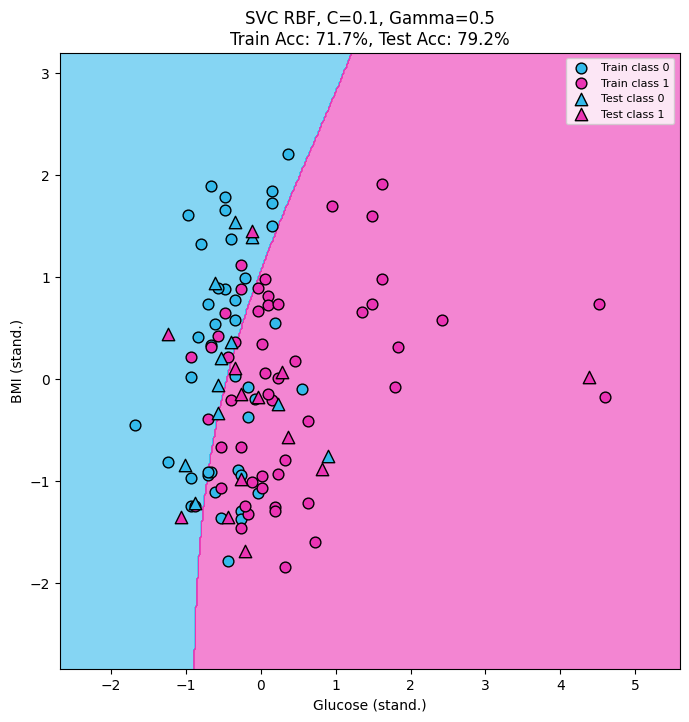

In [40]:
X_train_vis = X_stand_train
y_train_vis = y_stand_train
X_test_vis = X_stand_test
y_test_vis = y_stand_test

# Model SVC top 1
svc = SVC(kernel='rbf', C=0.5, gamma=0.1, random_state=42)
svc.fit(X_train_vis, y_train_vis)

# Obliczenie skuteczności
train_acc = accuracy_score(y_train_vis, svc.predict(X_train_vis)) * 100
test_acc = accuracy_score(y_test_vis, svc.predict(X_test_vis)) * 100

# Granica decyzyjna
h = 0.02
x_min, x_max = X_train_vis[:, 0].min() - 1, X_train_vis[:, 0].max() + 1
y_min, y_max = X_train_vis[:, 1].min() - 1, X_train_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = svc.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Kolory
color_0 = '#34baeb'
color_1 = '#eb34b4'
cmap_light = ListedColormap([color_0+'55', color_1+'55'])

plt.figure(figsize=(8,8))
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)

# Punkty treningowe - kółka
for cls, color in zip([0,1], [color_0, color_1]):
    plt.scatter(X_train_vis[y_train_vis==cls, 0],
                X_train_vis[y_train_vis==cls, 1],
                c=color, edgecolor='k', s=60, marker='o', label=f'Train class {cls}')

# Punkty testowe - trójkąty
for cls, color in zip([0,1], [color_0, color_1]):
    plt.scatter(X_test_vis[y_test_vis==cls, 0],
                X_test_vis[y_test_vis==cls, 1],
                c=color, edgecolor='k', s=80, marker='^', label=f'Test class {cls}')


plt.xlabel('Glucose (stand.)')
plt.ylabel('BMI (stand.)')
plt.title(f'SVC RBF, C=0.1, Gamma=0.5\nTrain Acc: {train_acc:.1f}%, Test Acc: {test_acc:.1f}%')
plt.legend(fontsize=8)
plt.show()

Dane były trudne do odseparowania liniowo - żadna kombinacja zmiennych (co pokazano na wykresie typu Pair plot) nie pozwoliła w łatwy sposób na liniowe odseparowanie danyhc. Najlepsze okazały się modele z jądrem typu RBF, a wysokie wyniki skuteczności uzyskały tez modele Sigmoid. Najlepszy zestaw parametrów wyświetlono na wykresie powyżej.

## Zadanie 9

Należy wyznaczyć macierze pomyłek dla klasyfikatora. Proszę dokonać wizualizacji wraz z kolorami na wykresie. Przykłady: 

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html#sklearn.metrics.confusion_matrix

https://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html#sphx-glr-auto-examples-model-selection-plot-confusion-matrix-py

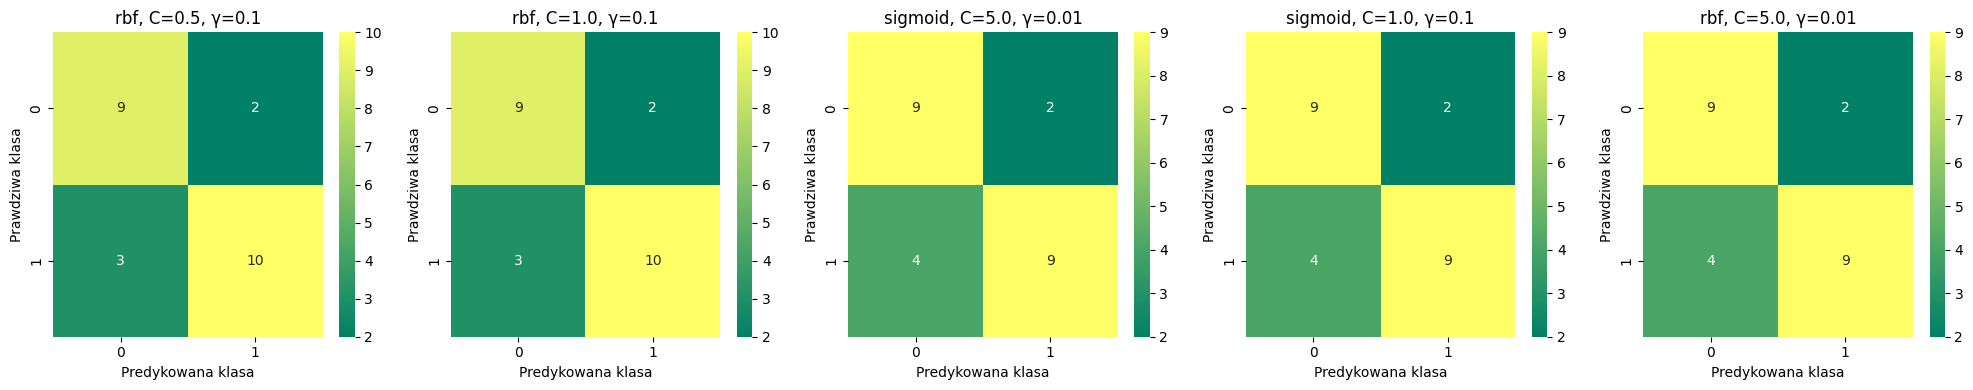

In [48]:
from sklearn.metrics import confusion_matrix

top_n = 5
labels = np.unique(y_stand_test)

top_models_params = df_results.sort_values('Test Accuracy [%]', ascending=False).head(top_n)

fig, axes = plt.subplots(1, top_n, figsize=(4*top_n, 4))

for i, (_, row) in enumerate(top_models_params.iterrows()):
    kernel = row['Kernel']
    C = row['C']
    gamma = row['Gamma'] if row['Gamma'] != '-' else 'scale'

    if kernel == 'linear':
        model = SVC(kernel=kernel, C=C, random_state=42)
    else:
        model = SVC(kernel=kernel, C=C, gamma=gamma, random_state=42)
    model.fit(X_stand_train, y_stand_train)

    y_pred = model.predict(X_stand_test)

    cm = confusion_matrix(y_stand_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='summer',
                xticklabels=labels, yticklabels=labels,
                ax=axes[i])
    axes[i].set_title(f'{kernel}, C={C}, γ={gamma}')
    axes[i].set_xlabel('Predykowana klasa')
    axes[i].set_ylabel('Prawdziwa klasa')

plt.tight_layout()
plt.show()

Macierze pomyłek są do siebie bardzo zbliżone we wszystkich konfiguracjach - widoczna jest różnica w zakfalifikowaniu jednego przypadku z klasy 1 jako 0.